In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/retail_sales_dataset.txt")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [6]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.dtypes

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [12]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [13]:
df["Total Amount"]

0       150
1      1000
2        30
3       500
4       100
       ... 
995      50
996      90
997     100
998     150
999     120
Name: Total Amount, Length: 1000, dtype: int64

In [14]:
df["Total Amount"].mean()

np.float64(456.0)

In [15]:
print("Average:", df["Total Amount"].mean())
print("Minimum:", df["Total Amount"].min())
print("Maximum:", df["Total Amount"].max())
print("Total Sales:", df["Total Amount"].sum())

Average: 456.0
Minimum: 25
Maximum: 2000
Total Sales: 456000


In [16]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
high_sales = df[df["Total Amount"] > 500]

high_sales.head(20)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
15,16,2023-02-17,CUST016,Male,19,Clothing,3,500,1500
19,20,2023-11-05,CUST020,Male,22,Clothing,3,300,900
25,26,2023-10-07,CUST026,Female,28,Electronics,2,500,1000
29,30,2023-10-29,CUST030,Female,39,Beauty,3,300,900
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200
34,35,2023-08-05,CUST035,Female,58,Beauty,3,300,900


In [20]:
df[df["Quantity"] >= 3].head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200
11,12,2023-10-30,CUST012,Male,35,Beauty,3,25,75
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500


In [21]:
df[df["Product Category"] == "Electronics"].head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000


In [22]:
df[
    (df["Product Category"] == "Electronics") &
    (df["Total Amount"] > 500)
].head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
12,13,2023-08-05,CUST013,Male,22,Electronics,3,500,1500
14,15,2023-01-16,CUST015,Female,42,Electronics,4,500,2000
25,26,2023-10-07,CUST026,Female,28,Electronics,2,500,1000
30,31,2023-05-23,CUST031,Male,44,Electronics,4,300,1200


In [23]:
df["Product Category"].unique()

<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str

In [24]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [25]:
df.groupby("Product Category")["Total Amount"].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

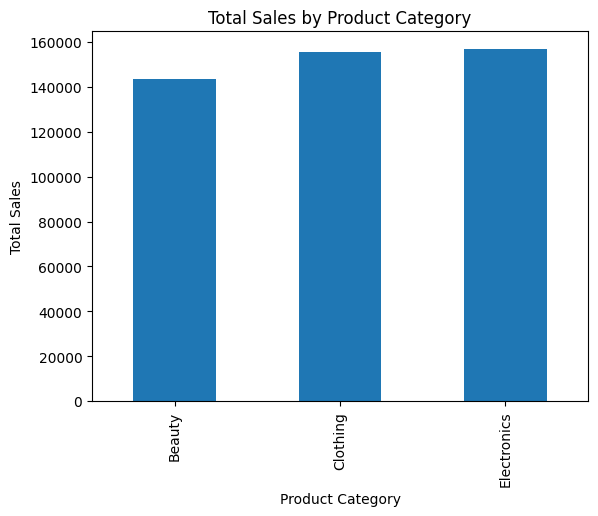

In [27]:
import matplotlib.pyplot as plt

df.groupby("Product Category")["Total Amount"].sum().plot(
    kind="bar"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()